# What is the most optimal skill to learn for Data Analysts?

#### Methodology

1. Continue from last notebook to find percent of postings with skill
2. Visualize median salary vs percent skill demand
3. (Optional) Determine if certain technologies are more prevalent

In [6]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [7]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

# Drop NaN values from the 'salary_year_avg' column for accurate visualization
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

df_DA_US_exploded = df_DA_US.explode('job_skills')

df_DA_US_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [8]:
df_skills = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_job_count = len(df_DA_US)

df_skills['skills_percentage'] = df_skills['count']/ df_job_count*100

skill_percent=5

df_high_demand_skill = df_skills[df_skills['skills_percentage']>skill_percent]

df_high_demand_skill

,count,median,skills_percentage
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


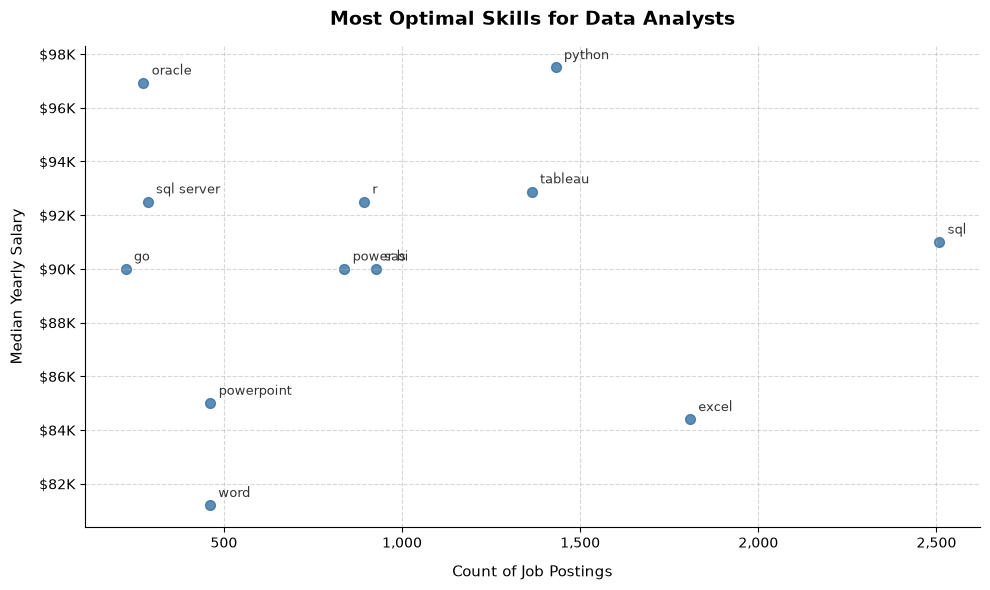

In [9]:
# 1. Create the scatter plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    df_high_demand_skill['count'], 
    df_high_demand_skill['median'], 
    color='#3470a3', 
    alpha=0.8, 
    s=50
)

# 2. Add text annotations with an offset (no adjustText needed)
for txt, row in df_high_demand_skill.iterrows():
    ax.annotate(
        txt, 
        xy=(row['count'], row['median']),
        xytext=(6, 6),  # Shifts text 6 points right & 6 points up
        textcoords='offset points',
        fontsize=9,
        color='#333333'
    )

# 3. Set axis labels and title
plt.xlabel('Count of Job Postings', fontsize=11, labelpad=10)
plt.ylabel('Median Yearly Salary', fontsize=11, labelpad=10)
plt.title('Most Optimal Skills for Data Analysts', fontsize=14, fontweight='bold', pad=15)

# 4. Format Y-axis as Currency ($100K) and X-axis with Commas (10,000)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x):,}'))

# 5. Add subtle background grid & clean up borders
plt.grid(True, linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [10]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['sheets',
  'cognos',
  'datarobot',
  'qlik',
  'excel',
  'visio',
  'spss',
  'sap',
  'microstrategy',
  'ssrs',
  'powerpoint',
  'word',
  'sas',
  'ms access',
  'msaccess',
  'spreadsheet',
  'sharepoint',
  'powerbi',
  'dax',
  'looker',
  'nuix',
  'outlook',
  'alteryx',
  'esquisse',
  'power bi',
  'ssis',
  'splunk',
  'tableau'],
 'programming': ['solidity',
  'matlab',
  'html',
  'javascript',
  'lisp',
  'objective-c',
  'nosql',
  't-sql',
  'visual basic',
  'cobol',
  'c++',
  'c',
  'fortran',
  'r',
  'julia',
  'f#',
  'golang',
  'clojure',
  'assembly',
  'dart',
  'lua',
  'perl',
  'visualbasic',
  'scala',
  'sas',
  'crystal',
  'mongodb',
  'php',
  'css',
  'groovy',
  'no-sql',
  'swift',
  'python',
  'powershell',
  'shell',
  'mongo',
  'kotlin',
  'sass',
  'rust',
  'delphi',
  'ruby',
  'vba',
  'elixir',
  'java',
  'ocaml',
  'apl',
  'erlang',
  'sql',
  'typescript',
  'c#',
  'bash',
  'vb.net',
  'haskell',
  'go',
  'pas

In [11]:
# turn dictionary into dataframe
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology


,technology,skills
0,analyst_tools,sheets
0,analyst_tools,cognos
0,analyst_tools,datarobot
0,analyst_tools,qlik
0,analyst_tools,excel
...,...,...
9,sync,twilio
9,sync,zoom
9,sync,webex
9,sync,rocketchat


In [13]:
# merge df_DA_skills and df_technology
df_DA_skills_tech = df_skills.merge(df_technology, left_on='job_skills', right_on='skills')

df_DA_skills_tech

,count,median,skills_percentage,technology,skills
0,2508,91000.0,57.655172,programming,sql
1,1808,84392.0,41.563218,analyst_tools,excel
2,1431,97500.0,32.896552,programming,python
3,1364,92875.0,31.356322,analyst_tools,tableau
4,926,90000.0,21.287356,analyst_tools,sas
...,...,...,...,...,...
169,1,100000.0,0.022989,libraries,theano
170,1,65000.0,0.022989,programming,typescript
171,1,147500.0,0.022989,cloud,vmware
172,1,65000.0,0.022989,webframeworks,vue


In [17]:
df_DA_skills_tech_high_demand = df_DA_skills_tech[df_DA_skills_tech['skills_percentage'] > skill_percent]

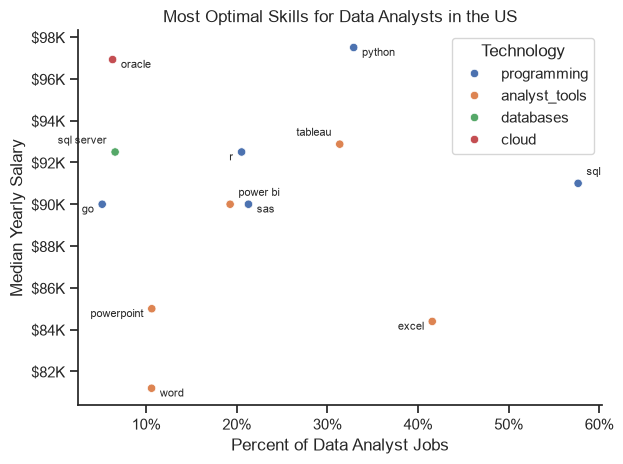

In [29]:
sns.scatterplot(
    data=df_DA_skills_tech_high_demand,
    x='skills_percentage',
    y='median',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

# Add text labels with dynamic offsets/alignments to prevent collision
for i, txt in enumerate(df_high_demand_skill.index):
    x_val = df_high_demand_skill['skills_percentage'].iloc[i]
    y_val = df_high_demand_skill['median'].iloc[i]
    
    # Alternate position based on index or position to avoid collisions
    x_offset = 6 if i % 2 == 0 else -6
    y_offset = 6 if i % 3 == 0 else -6
    ha = 'left' if x_offset > 0 else 'right'
    
    plt.annotate(
        txt, 
        (x_val, y_val),
        xytext=(x_offset, y_offset),
        textcoords='offset points',
        ha=ha,
        fontsize=8
    )

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')
plt.legend(title='Technology')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and display plot 
plt.tight_layout()
plt.show()